# 06 Hyperparameter Tuning (Optuna + MLflow)


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import optuna
import pandas as pd
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

/home/amir/dev/lol-match-oracle/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from oracle.models import TrainingConfig
from oracle.optimization import OptimizationConfig, run_model_optimization
from oracle.utils import load_yaml_config

training_mapping = load_yaml_config(PROJECT_ROOT / "configs" / "training.yaml")
model_mapping = load_yaml_config(PROJECT_ROOT / "configs" / "model.yaml")

training_config = TrainingConfig.from_mapping(
    training_mapping,
    base_dir=PROJECT_ROOT,
    experiment_name_override="02-advanced-models",
    run_name_override="notebook-optuna-best-model",
)
optimization_config = OptimizationConfig.from_mapping(
    model_mapping,
    base_dir=PROJECT_ROOT,
)
optimization_config.n_trials = 20

In [3]:
result = run_model_optimization(
    model_name="xgboost",
    training_config=training_config,
    model_mapping=model_mapping,
    optimization_config=optimization_config,
)

result

[I 2026-04-25 14:53:16,317] Using an existing study with name 'lfd-optuna-xgboost' instead of creating a new one.
[I 2026-04-25 14:53:30,522] Trial 30 finished with value: 0.9986883362267286 and parameters: {'n_estimators': 650, 'learning_rate': 0.06246137457638295, 'max_depth': 10, 'subsample': 0.6663575602539983, 'colsample_bytree': 0.9678337970557095, 'reg_alpha': 0.010511671559280861, 'reg_lambda': 3.987321226150173e-08, 'min_child_weight': 4.844968723465524, 'gamma': 2.8527393244084163}. Best is trial 30 with value: 0.9986883362267286.
[I 2026-04-25 14:53:53,598] Trial 31 finished with value: 0.9986870729142192 and parameters: {'n_estimators': 650, 'learning_rate': 0.06018874855681135, 'max_depth': 10, 'subsample': 0.6342082801925268, 'colsample_bytree': 0.9668614339214231, 'reg_alpha': 0.008830526137085626, 'reg_lambda': 4.961165062511121e-08, 'min_child_weight': 5.238263700227257, 'gamma': 2.958418179650298}. Best is trial 30 with value: 0.9986883362267286.
[I 2026-04-25 14:54:1

OptimizationResult(model_name='xgboost', study_name='lfd-optuna-xgboost', parent_run_id='e63466ee019c406c8c39f438d94cdc88', best_value=0.9986921106062214, best_params={'n_estimators': 500, 'learning_rate': 0.04303110791480862, 'max_depth': 10, 'subsample': 0.8168165679905873, 'colsample_bytree': 0.9473668173927172, 'reg_alpha': 2.0248813957570868e-06, 'reg_lambda': 0.020211660841900004, 'min_child_weight': 9.924489371326441, 'gamma': 3.9674650045956326, 'early_stopping_rounds': 30, 'eval_metric': 'logloss', 'n_jobs': -1}, initial_trials=30, total_trials=50, added_trials=20, best_model_path=PosixPath('/home/amir/dev/lol-match-oracle/models/02-advanced-models/xgboost/e63466ee019c406c8c39f438d94cdc88/model.pkl'), best_params_path=PosixPath('/home/amir/dev/lol-match-oracle/reports/optimization/lfd-optuna-xgboost_best_params.json'), best_model_metadata_path=PosixPath('/home/amir/dev/lol-match-oracle/reports/optimization/lfd-optuna-xgboost_best_model_metadata.json'), study_summary_path=Posix

In [4]:
summary = pd.DataFrame(
    [
        {
            "model": result.model_name,
            "study_name": result.study_name,
            "best_value": result.best_value,
            "initial_trials": result.initial_trials,
            "total_trials": result.total_trials,
            "added_trials": result.added_trials,
            "parent_run_id": result.parent_run_id,
        }
    ]
)
summary

,model,study_name,best_value,initial_trials,total_trials,added_trials,parent_run_id
0,xgboost,lfd-optuna-xgboost,0.998692,30,50,20,e63466ee019c406c8c39f438d94cdc88


/tmp/ipykernel_47223/4209091706.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)
/tmp/ipykernel_47223/4209091706.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

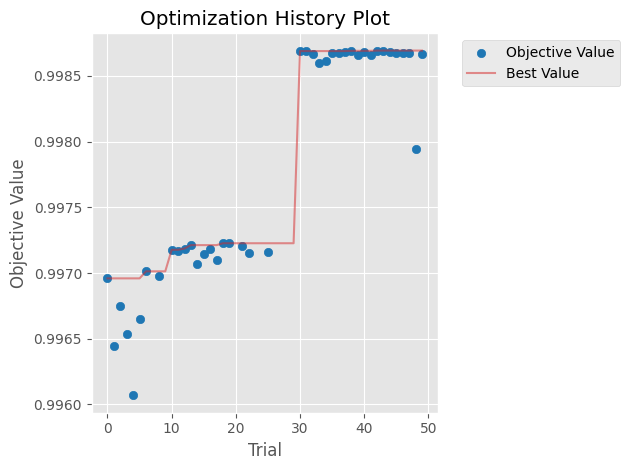

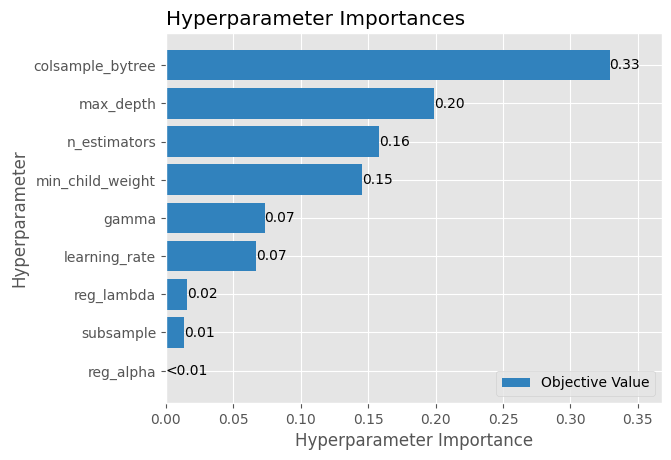

In [5]:
study = optuna.load_study(study_name=result.study_name, storage=result.storage_url)

plot_optimization_history(study)
plot_param_importances(study)